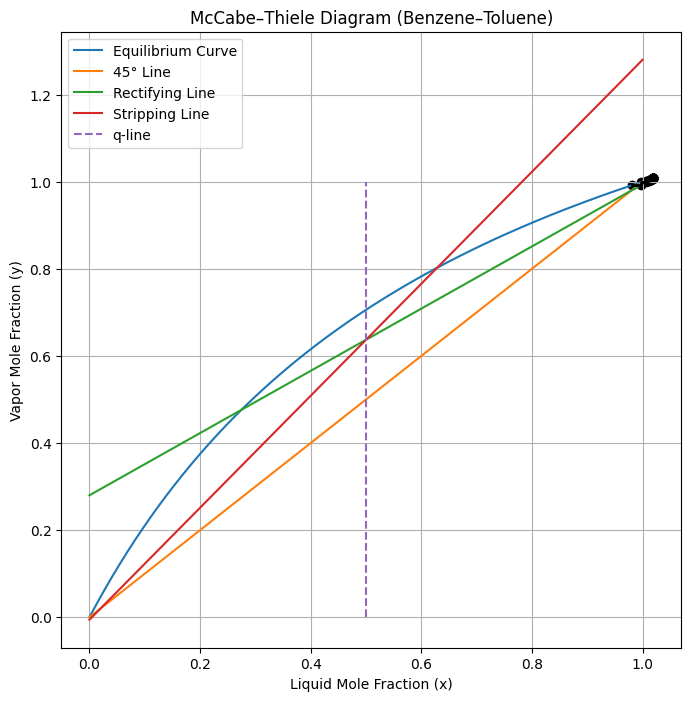


Estimated Number of Theoretical Stages: 21


In [14]:
import numpy as np
import matplotlib.pyplot as plt



alpha = 2.4     # relative volatility

xD = 0.98       # distillate composition
xB = 0.02       # bottoms composition
xF = 0.50       # feed composition

R = 2.5         # reflux ratio
q = 1           # saturated liquid feed



# Equilibrium relation


def y_eq(x):
    return (alpha*x)/(1+(alpha-1)*x)



# Operating lines


def rectifying(x):
    return (R/(R+1))*x + xD/(R+1)


# q-line (vertical because q = 1)

x_q = np.full(200, xF)
y_q = np.linspace(0,1,200)


# Intersection point

x_int = xF
y_int = rectifying(x_int)


# stripping line

def stripping(x):
    slope = (y_int-xB)/(x_int-xB)
    return slope*(x-xB)+xB



# Generate curves


x = np.linspace(0,1,500)

y_equilibrium = y_eq(x)
y_rect = rectifying(x)
y_strip = stripping(x)



# Stage stepping


stages = 0
x_current = xD

stage_x = []
stage_y = []

while x_current > xB:

    # horizontal to equilibrium
    y_current = y_eq(x_current)

    stage_x.append(x_current)
    stage_y.append(y_current)

    # vertical to operating line
    if x_current > xF:
        x_next = (y_current - xD/(R+1))*((R+1)/R)
    else:
        slope = (y_int-xB)/(x_int-xB)
        x_next = (y_current - xB)/slope + xB

    stage_x.append(x_next)
    stage_y.append(y_current)

    x_current = x_next
    stages += 1

    if stages > 20:
        break


# Plot diagram


plt.figure(figsize=(8,8))

plt.plot(x,y_equilibrium,label="Equilibrium Curve")
plt.plot(x,x,label="45° Line")

plt.plot(x,y_rect,label="Rectifying Line")
plt.plot(x,y_strip,label="Stripping Line")

plt.plot(x_q,y_q,'--',label="q-line")

plt.plot(stage_x,stage_y,'k-',linewidth=2)
plt.scatter(stage_x,stage_y,color='black')

plt.xlabel("Liquid Mole Fraction (x)")
plt.ylabel("Vapor Mole Fraction (y)")

plt.title("McCabe–Thiele Diagram (Benzene–Toluene)")

plt.legend()
plt.grid()

plt.savefig("mccabe_thiele_complete.png",dpi=400)

plt.show()

print("\nEstimated Number of Theoretical Stages:",stages)

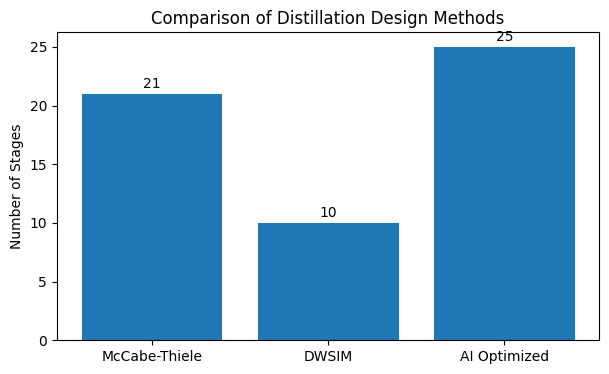

In [13]:
methods = ["McCabe-Thiele","DWSIM","AI Optimized"]
stages_values = [21,10,25]

plt.figure(figsize=(7,4))

bars = plt.bar(methods, stages_values)

plt.ylabel("Number of Stages")
plt.title("Comparison of Distillation Design Methods")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,y+0.5,int(y),
             ha='center')

plt.savefig("stage_comparison.png",dpi=400)

plt.show()